# ResNet18 Baseline - 2000 Samples

This notebook trains a ResNet18 model for document type classification using 2000 samples from the dataset.

**Model Architecture:** ResNet18 (trained from scratch, no pre-training)  
**Dataset Size:** 2000 images (balanced across 3 classes)  
**Training Configuration:**
- Batch size: 64
- Learning rate: 0.0000005
- Epochs: 30
- Optimizer: Adam with weight decay 1e-4
- Dropout: 0.3


## Data Loading and Splitting

Load the dataset CSV file, sample 2000 images (if needed), and split into train/validation/test sets with stratified sampling to maintain class balance.


## Custom Dataset Class

Define a PyTorch Dataset class that loads images from file paths and applies transformations. Maps labels to numeric values (id_card=0, passport=1, driver_license=2).


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Set the number of images to use (None = use entire dataset)
SAMPLE_SIZE = 2000

df = pd.read_csv("/Users/roy-siftt/final-project/datasets/idnet/document_type_classification_country_split/data/dataset.csv")

print(f"Original dataset size: {len(df)} images")
print(f"\nOriginal distribution:")
print(df['label'].value_counts().sort_index())

# If we want a smaller dataset, sample proportionally
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    df = df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(n=min(len(x), int(SAMPLE_SIZE * len(x) / len(df))), random_state=42)
    ).reset_index(drop=True)
    print(f"\nDataset size after sampling: {len(df)} images")
    print(f"\nDistribution after sampling:")
    print(df['label'].value_counts().sort_index())

# Split into train/test/val
train_df, test_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df['label'], random_state=42)

print(f"\n{'='*60}")
print(f"Final Split:")
print(f"{'='*60}")

print(f"\nTrain Set: {len(train_df)} images")
print(train_df['label'].value_counts().sort_index())
print(f"   Total: {train_df['label'].value_counts().sum()}")

print(f"\nValidation Set: {len(val_df)} images")
print(val_df['label'].value_counts().sort_index())
print(f"   Total: {val_df['label'].value_counts().sum()}")

print(f"\nTest Set: {len(test_df)} images")
print(test_df['label'].value_counts().sort_index())
print(f"   Total: {test_df['label'].value_counts().sum()}")

print(f"\n{'='*60}")
print(f"Saving files...")

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

print(f"Files saved successfully!")
print(f"{'='*60}")

Original dataset size: 3600 images

Original distribution:
label
driver_license    1200
id_card           1200
passport          1200
Name: count, dtype: int64

Dataset size after sampling: 1998 images

Distribution after sampling:
label
driver_license    666
id_card           666
passport          666
Name: count, dtype: int64

Final Split:

Train Set: 1443 images
label
driver_license    481
id_card           481
passport          481
Name: count, dtype: int64
   Total: 1443

Validation Set: 255 images
label
driver_license    85
id_card           85
passport          85
Name: count, dtype: int64
   Total: 255

Test Set: 300 images
label
driver_license    100
id_card           100
passport          100
Name: count, dtype: int64
   Total: 300

Saving files...
Files saved successfully!


/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_59385/2590842997.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('label', group_keys=False).apply(


## Data Augmentation and Transforms

Define image transformations for training (with strong augmentation) and validation/test (without augmentation). Uses ImageNet normalization statistics.


In [2]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class DocumentDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

        # Normalize labels (lowercase + strip spaces)
        self.df['label'] = self.df['label'].str.lower().str.strip()

        # Label mapping
        self.label_map = {
            "id_card": 0,
            "passport": 1,
            "driver_license": 2
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert("RGB")

        label_str = row['label']

        if label_str not in self.label_map:
            raise ValueError(f"Label '{label_str}' not found in label_map!")

        label = self.label_map[label_str]

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label)

## Create DataLoaders

Create PyTorch DataLoaders for train, validation, and test sets with appropriate batch sizes and shuffling.


In [3]:
from torchvision import transforms

# Transform with strong data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),              # Random crop instead of center
    transforms.RandomHorizontalFlip(p=0.3),  # Horizontal flip sometimes
    transforms.RandomRotation(15),           # Random rotation
    transforms.ColorJitter(                  # Color/brightness changes
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.1
    ),
    transforms.RandomAffine(                 # Geometric transformations
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3)          # Random erasing
])

# Transform for validation/test - without augmentation
val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])


## ResNet18 Model Definition

Define the ResNet18 classifier model. The model is trained from scratch (no pre-training). The final fully connected layer is replaced with a dropout layer followed by a linear layer for 3 classes.


In [4]:
from torch.utils.data import DataLoader

# Use different transforms for train and val/test
train_dataset = DocumentDataset(pd.read_csv("train.csv"), train_transform)
val_dataset   = DocumentDataset(pd.read_csv("val.csv"), val_test_transform)
test_dataset  = DocumentDataset(pd.read_csv("test.csv"), val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Dataset sizes:")
print(f"   Train: {len(train_dataset)}")
print(f"   Val:   {len(val_dataset)}")
print(f"   Test:  {len(test_dataset)}")

Dataset sizes:
   Train: 1443
   Val:   255
   Test:  300


## Visualize Sample Batch

Display a sample batch of training images to verify data loading and augmentation are working correctly.


In [5]:
import torch
import torch.nn as nn
from torchvision import models

class ResNet18Classifier(nn.Module):
    def __init__(self, num_classes=3, pretrained=True, dropout=0.5):
        super(ResNet18Classifier, self).__init__()
        
        # Load ResNet18 pre-trained on ImageNet
        if pretrained:
            self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        else:
            self.resnet = models.resnet18(weights=None)
        
        # Replace the final layer and add Dropout for regularization
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, num_classes)
        )
        
    def forward(self, x):
        return self.resnet(x)

## Verify Dataset Loading

Check that images and labels are being loaded correctly by printing sample paths and labels.


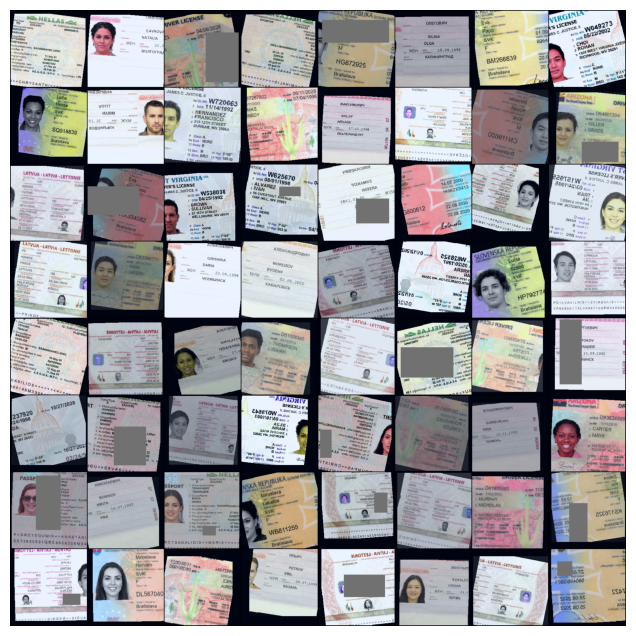

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def show_batch(loader):
    imgs, labels = next(iter(loader))
    grid = torchvision.utils.make_grid(imgs, nrow=8, normalize=True)
    plt.figure(figsize=(12,8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.axis('off')

show_batch(train_loader)

## Training Setup and Execution

Initialize the model, loss function, and optimizer. Train the model for multiple epochs, evaluating on validation set after each epoch. Finally, evaluate on the test set and visualize training curves.


In [7]:
for i in range(10):
    print("PATH:", train_dataset.df.iloc[i]['image_path'])
    print("LABEL:", train_dataset.df.iloc[i]['label'])
    img, lbl = train_dataset[i]
    print("LOADER LABEL:", lbl)
    print("----")

PATH: images/02721.png
LABEL: passport
LOADER LABEL: tensor(1)
----
PATH: images/01929.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: images/03757.png
LABEL: id_card
LOADER LABEL: tensor(0)
----
PATH: images/01866.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: images/01830.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: images/02160.png
LABEL: driver_license
LOADER LABEL: tensor(2)
----
PATH: images/00984.png
LABEL: id_card
LOADER LABEL: tensor(0)
----
PATH: images/01499.png
LABEL: id_card
LOADER LABEL: tensor(0)
----
PATH: images/00982.png
LABEL: id_card
LOADER LABEL: tensor(0)
----
PATH: images/01125.png
LABEL: id_card
LOADER LABEL: tensor(0)
----


Using device: mps
Model: ResNet18 (Training from scratch - NO pre-training!)
Number of parameters: 11,178,051
Learning rate: 5e-07
Dropout: 0.3

Starting training...


=== Initial Evaluation (Before Training) ===

Sample predictions (first 20):
  True: 1, Predicted: 2, ✗
  True: 1, Predicted: 2, ✗
  True: 1, Predicted: 2, ✗
  True: 0, Predicted: 2, ✗
  True: 2, Predicted: 2, ✓
  True: 1, Predicted: 2, ✗
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 0, Predicted: 2, ✗
  True: 0, Predicted: 2, ✗
  True: 2, Predicted: 2, ✓
  True: 2, Predicted: 2, ✓
  True: 0, Predicted: 2, ✗
  True: 1, Predicted: 2, ✗
  True: 0, Predicted: 2, ✗
  True: 1, Predicted: 2, ✗
  True: 1, Predicted: 2, ✗
  True: 0, Predicted: 2, ✗
  True: 1, Predicted: 2, ✗
  True: 1, Predicted: 2, ✗

Confusion Matrix:
[[  0   0 481]
 [  0   0 481]
 [  0   0 481]]

Train Acc (before): 0.3333
Val Acc (before):   0.3333

=== Epoch 1 ===


Training: 100%|██████████| 23/23 [00:32<00:00,  1.42s/it]


Train Loss: 1.1345 | Train Acc: 0.3333
Val   Loss: 1.1498 | Val   Acc: 0.3333

=== Epoch 2 ===


Training: 100%|██████████| 23/23 [00:28<00:00,  1.22s/it]


Train Loss: 1.0964 | Train Acc: 0.3777
Val   Loss: 1.0726 | Val   Acc: 0.3569

=== Epoch 3 ===


...

Train Loss: 0.8507 | Train Acc: 0.6306
Val   Loss: 0.6687 | Val   Acc: 0.8157

=== Epoch 29 ===


Training: 100%|██████████| 23/23 [00:28<00:00,  1.22s/it]


Train Loss: 0.8376 | Train Acc: 0.6431
Val   Loss: 0.6433 | Val   Acc: 0.8235

=== Epoch 30 ===


Training: 100%|██████████| 23/23 [00:28<00:00,  1.23s/it]


Train Loss: 0.8312 | Train Acc: 0.6500
Val   Loss: 0.6400 | Val   Acc: 0.8235

FINAL EVALUATION ON TEST SET (Never seen during training)

Sample predictions (first 20):
  True: 2, Predicted: 0, ✗
  True: 1, Predicted: 1, ✓
  True: 0, Predicted: 0, ✓
  True: 0, Predicted: 0, ✓
  True: 2, Predicted: 0, ✗
  True: 2, Predicted: 2, ✓
  True: 1, Predicted: 1, ✓
  True: 0, Predicted: 0, ✓
  True: 0, Predicted: 0, ✓
  True: 0, Predicted: 0, ✓
  True: 0, Predicted: 0, ✓
  True: 0, Predicted: 0, ✓
  True: 1, Predicted: 1, ✓
  True: 2, Predicted: 0, ✗
  True: 1, Predicted: 1, ✓
  True: 0, Predicted: 0, ✓
  True: 2, Predicted: 2, ✓
  True: 1, Predicted: 1, ✓
  True: 1, Predicted: 1, ✓
  True: 2, Predicted: 2, ✓

Confusion Matrix:
[[100   0   0]
 [  0 100   0]
 [ 46   0  54]]

Final Test Accuracy: 0.8467
Final Test Loss: 0.6145


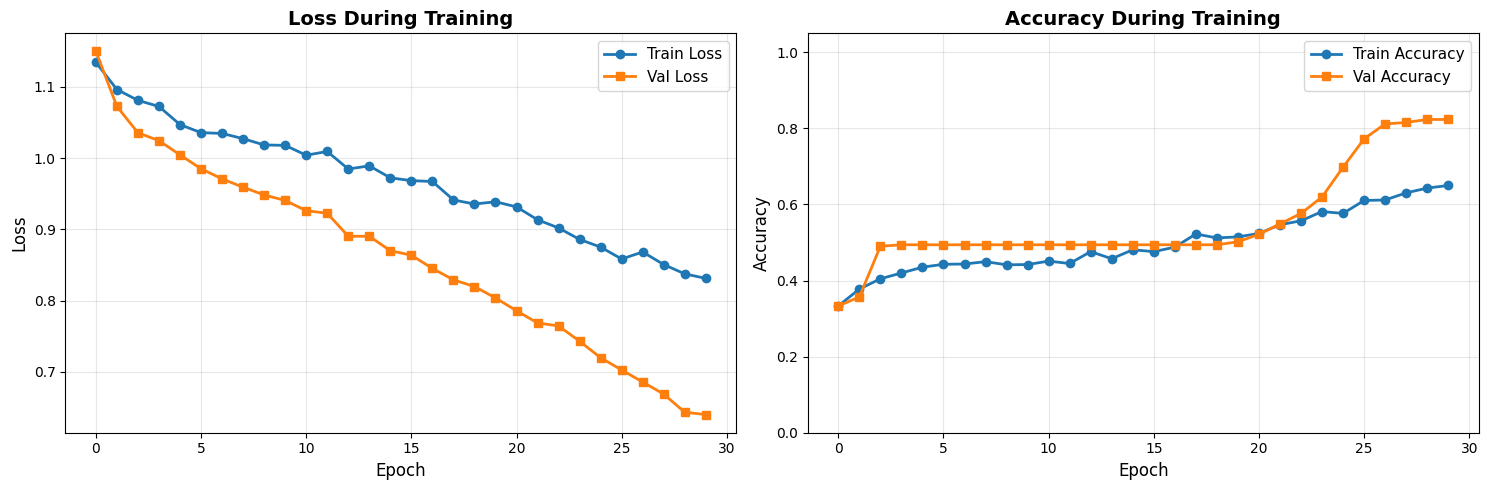


Training Summary:
Best Train Accuracy: 0.6500 (Epoch 30)
Best Val Accuracy:   0.8235 (Epoch 29)
Final Test Accuracy: 0.8467

Successfully observed real learning process from scratch!


In [8]:
import torch
from torch.optim import Adam
import torch.nn as nn
from tqdm import tqdm
import numpy as np

# Device selection: CUDA (NVIDIA GPU) -> MPS (Apple Silicon GPU) -> CPU
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = "mps"  # Apple Silicon GPU (M1/M2/M3)
else:
    device = "cpu"

# Create ResNet18 model that will learn from scratch
# pretrained=False -> no prior knowledge, model learns everything from scratch
model = ResNet18Classifier(num_classes=3, pretrained=False, dropout=0.3).to(device)

criterion = nn.CrossEntropyLoss()

# Learning rate for model learning from scratch
optimizer = Adam(model.parameters(), lr=0.0000005, weight_decay=1e-4)

print(f"Using device: {device}")
print(f"Model: ResNet18 (Training from scratch - NO pre-training!)")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Dropout: 0.3")
print("\nStarting training...\n")

def evaluate(loader, verbose=False):
    model.eval()
    total = 0
    correct = 0
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    avg_loss = total_loss / len(loader)
    
    if verbose:
        # Detailed check - what is the model predicting?
        print(f"\nSample predictions (first 20):")
        for i in range(min(20, len(all_preds))):
            print(f"  True: {all_labels[i]}, Predicted: {all_preds[i]}, {'✓' if all_preds[i] == all_labels[i] else '✗'}")
        
        # Confusion matrix
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(all_labels, all_preds)
        print(f"\nConfusion Matrix:")
        print(cm)
    
    return accuracy, avg_loss

# Initial evaluation before training
print("\n" + "="*60)
print("=== Initial Evaluation (Before Training) ===")
print("="*60)
initial_train_acc, initial_train_loss = evaluate(train_loader, verbose=True)
initial_val_acc, initial_val_loss = evaluate(val_loader)
print(f"\nTrain Acc (before): {initial_train_acc:.4f}")
print(f"Val Acc (before):   {initial_val_acc:.4f}")
print("="*60)

# Track training progress - save performance at each epoch
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

num_epochs = 30  # More epochs to see learning process

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    print(f"\n=== Epoch {epoch+1} ===")

    # tqdm for nice progress bar
    for imgs, labels in tqdm(train_loader, desc="Training"):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation calculations
    train_accuracy, train_loss = evaluate(train_loader)
    val_accuracy, val_loss = evaluate(val_loader)
    
    # Save to history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_accuracy)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_accuracy:.4f}")

print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET (Never seen during training)")
print("="*60)
test_accuracy, test_loss = evaluate(test_loader, verbose=True)
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

# Display training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graph 1: Loss over time
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Graph 2: Accuracy over time
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Training Summary:")
print("="*60)
print(f"Best Train Accuracy: {max(history['train_acc']):.4f} (Epoch {history['train_acc'].index(max(history['train_acc']))+1})")
print(f"Best Val Accuracy:   {max(history['val_acc']):.4f} (Epoch {history['val_acc'].index(max(history['val_acc']))+1})")
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"\nSuccessfully observed real learning process from scratch!")